### **NON-LINEAR PROGRAMMING**

Nonlinear programming (NLP) is about optimizing an objective function when either the objective or at least one constraint is nonlinear in the decision variables.

#### **_Constrained Regression_**

A university wishes to assess the job placements of its graduates. For simplicity, it assumes that each graduate accepts either a government, industrial, or academic position. Let $ N_j =$ Number of graduates in year $j$ $(j = 1,2,...,n) $ , and let $G_j$, $I_j$, and $A_j$ denote the number entering government, industry, and academia, respectively, in year $j$ $(G_j + I_j + A_j = N_j)$.

One model being considered assumes that a given fraction of the student population joins each job category each year. If these fractions are denoted as $λ_1$, $λ_2$, and $λ_3$, then the predicted number entering the job categories in year $j$ is given by the expressions
$$\hat{G}_j = λ_1N_j,$$
$$\hat{I}_j = λ_2N_j,$$
$$\hat{A}_j = λ_3N_j.$$

A reasonable performance measure of the model’s validity might be the difference between the actual number of graduates $G_j$, $I_j$, and $A_j$ entering the three job categories and the predicted numbers $\hat{G}_j$, $\hat{I}_j$, and $\hat{A}_j$, as in the least-squares estimate:

$$Minimize \sum_{j=1}^{n} = [(G_j − \hat{G}_j)^2 +(I_j − \hat{I}_j)^2 + (Aj − \hat{A}_j)^2],$$

subject to the constraint that all graduates are employed in one of the professions. In terms of the fractions entering each profession, the model can be written as:

$$Minimize \sum_{j=1}^{n} [(G_j −λ_1N_j)^2 +(I_j −λ_2N_j)^2 +(A_j −λ_3N_j)^2],$$

subject to:

$$λ_1 + λ_2 + λ_3 = 1,$$
$$λ_1 \ge 0,λ_2 \ge 0, λ_3 \ge 0.$$

This is a nonlinear program in three variables $λ_1$, $λ_2$, and $λ_3$.

In [5]:
# For this problem we will use the scipy.optimize.minimize library

# Import the libraries we are going to use
from scipy.optimize import minimize
import numpy as np

For $λ_1$ ignoring constraints, we want to minimize
$$ J_1 (h_1) = \sum_{j=1}^{n} (G_j - λ_1N_j)^2 $$

1. We differentiate with respect to $λ_1$ and set it equal to $0$:
$$ \frac{dJ_1}{dλ_1} = \sum_{j=1}^{n} 2(G_j - λ_1N_j)(-N_j) = 0 $$
2. We rearrange:
$$ \sum_{j=1}^{n} N_jG_j - λ_1 \sum{j=1}^{n} N_j^2 = 0 $$
3. We clear:
$$λ_1^* = \frac{\sum_{j=1}^{n} N_jG_j}{\sum_{j=1}^{n} N_j^2}$$

Analogously:
$$λ_2^* = \frac{\sum_{j=1}^{n} N_jI_j}{\sum_{j=1}^{n} N_j^2}$$
$$λ_3^* = \frac{\sum_{j=1}^{n} N_jA_j}{\sum_{j=1}^{n} N_j^2}$$

Then the restrictions:
- let $\ge 0$
- and add $1$

In [6]:
# The objective function (Error)
def objective(lamb, N, G, I, A):
    """
    Calculate the total error between the actual data and the model predictions using λ1, λ2, λ3.

    Args:
        lamb: list of three fractions (λ1, λ2, λ3)
        N, G, I, A: data lists for each year
    """
    # For each year, sum the squared errors in each sector
    l1, l2, l3 = lamb
    err = 0 # inicialices the total error

    # Iterate simultaneously over the data for each year (Nj, Gj, Ij, Aj)
    for Nj, Gj, Ij, Aj in zip(N, G, I, A):
        # Calculate the squared error for each sector in the current year (j) and add it to the total
        err += (Gj - l1*Nj)**2 + (Ij - l2*Nj)**2 + (Aj - l3*Nj)**2
    return err



# Definition of the Equality Constraint
def constraint_sum(lamb):
    """
    Force that the sum of the fractions is equal to 1 (λ1 + λ2 + λ3 = 1)

    Args:
        lamb: parameter vector
    """
    # Returns zero only if the constraint is met
    return lamb[0] + lamb[1] + lamb[2] - 1
    # If lamb[0] + lamb[1] + lamb[2] = 1, the return is 1 - 1 = 0



# Simulation and Data Preparation
# Simulate 10 years of data
n = 10
# Generates 10 random values for N, G, and I within their ranges
N = np.random.randint(40, 100, size=n) # Total number of graduates each year
G = np.random.randint(10, 30, size=n) # Government
I = np.random.randint(10, 40, size=n) # Industry
A = N - G - I # Academic

print(f"N = {N}, \nG = {G}, \nI = {I}, \nA = {A}\n") # Print the generated data



# Optimization Settings
x0 = [0.3, 0.4, 0.3] # initial starting point for the search algorithm (x0)
bounds = [(0,1), (0,1), (0,1)] # inequality constraints that ensure that each fraction is between 0 and 1

# Definition of the sum restriction:
constraints = [{'type': 'eq', # 'eq' means equality restriction (equal to 0)
                'fun': constraint_sum}]



# Optimizer Execution
result = minimize(objective, # function to minimize (the error)
                  x0, # starting point
                  args=(N, G, I, A), # fixed arguments converted to 'objective'
                  method='SLSQP', # algorithm (SLSQP: Sequential Least Squares Programming), ideal for problems with constraints
                  bounds=bounds, # boundary restrictions (0 <= λk <= 1)
                  constraints=constraints) # equality constraint (λ1 + λ2 + λ3 = 1)

# Print the final values of (λ1, λ2, λ3) that minimize the error under the constraints
print("Optimal lambdas:", result.x)

N = [56 64 78 62 65 74 65 67 79 66], 
G = [28 24 12 20 16 19 28 14 14 16], 
I = [37 30 37 35 13 10 23 13 19 24], 
A = [-9 10 29  7 36 45 14 40 46 26]

Optimal lambdas: [0.27388894 0.34834965 0.37776141]


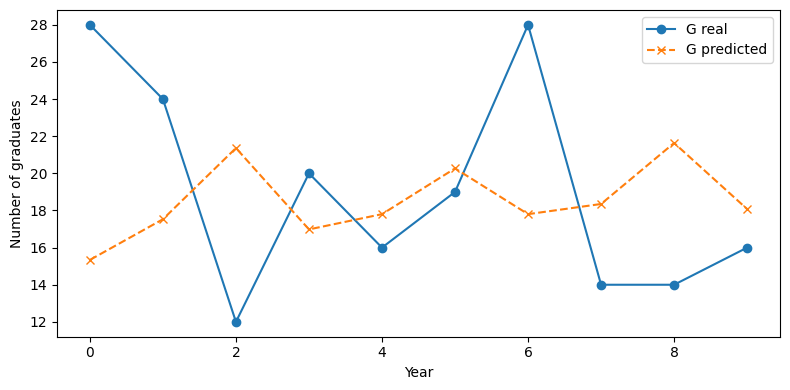

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Extract the optimal lambda values from the minimization result
l1, l2, l3 = result.x

# Calculating Predictions
# Prediction = Optimal Lambda * N
G_hat = l1 * np.array(N)
I_hat = l2 * np.array(N)
A_hat = l3 * np.array(N)

# Data visualization (government sector)
plt.figure(figsize=(8,4))
plt.plot(G, 'o-', label='G real')
plt.plot(G_hat, 'x--', label='G predicted')
plt.legend()
plt.xlabel('Year')
plt.ylabel('Number of graduates')
plt.tight_layout()
plt.show()

The line graph compares the actual placement of graduates in government ($G$ actual) with the model's prediction ($\hat{G}$ predicted) and demonstrates that the model is too simplistic to capture reality. The actual line is highly volatile (full of peaks and valleys), reflecting the significant year-over-year fluctuations in government sector demand; however, the predicted line is much smoother because the model assumes an optimized constant ratio ($\lambda_1^*$), meaning it only reflects changes in the total number of graduates ($N$). Consequently, the model finds the best average ratio but fails to predict data for individual years with high volatility.

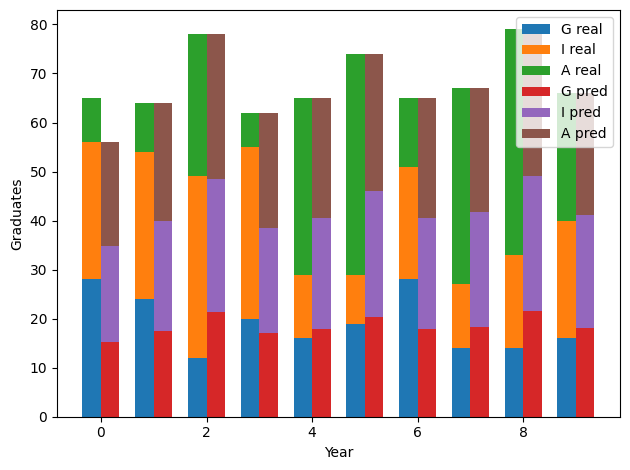

In [9]:
import matplotlib.pyplot as plt
import numpy as np

years = np.arange(len(N)) # create x-axis

# Calculate the predicted time series for each sector
G_hat = l1 * np.array(N)
I_hat = l2 * np.array(N)
A_hat = l3 * np.array(N)

width = 0.35 # width of each individual bar for grouping

# Predicted bars (left group)
# They are positioned to the left of the center of the year (years - width/2)
plt.bar(years - width/2, G, width, label='G real') # real G-bar (base 0)
plt.bar(years - width/2, I, width, bottom=G, label='I real') # real I bar, stacked on real G (bottom=G)
plt.bar(years - width/2, A, width, bottom=np.array(G)+np.array(I), label='A real') # real A bar, stacked on real G + I (bottom=G+I)

# Predicted bars (right group)
# They are positioned to the right of the center of the year (years + width/2)
plt.bar(years + width/2, G_hat, width, label='G pred') # predicted G-bar (base 0)
plt.bar(years + width/2, I_hat, width, bottom=G_hat, label='I pred') # predicted bar I, stacked on predicted G (bottom=G_hat)
plt.bar(years + width/2, A_hat, width, bottom=G_hat+I_hat, label='A pred') # predicted bar A, stacked on G_hat + I_hat (bottom=G_hat+I_hat)

plt.xlabel('Year')
plt.ylabel('Graduates')
plt.legend()
plt.tight_layout()
plt.show()


The stacked bar chart shows that the model accurately predicts the total number of graduates each year (the height of the bars is the same), which satisfies the constraint $\lambda_1 + \lambda_2 + \lambda_3 = 1$. However, it fails to predict the internal distribution (the colors or proportions of sectors $G$, $I$, $A$) in specific years, meaning that, although the total is correct, the model fails to predict which sector the graduates will actually go to.

_The problem is located at the following link:_ https://web.mit.edu/15.053/www/AMP-Chapter-13.pdf*, in the pages 412-413.*